# A04 Special-Bin Deltas Against SASRec

Each dataset/bin panel uses the same appendix bar+line tone, with dataset names printed by the cell rather than placed inside the plot.

In [5]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NB_ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp/appendix')
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import appendix_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
load_csv = viz.load_csv
load_json = viz.load_json
dataset_label = viz.dataset_label
bar_line_panel = viz.bar_line_panel
single_subfigure_axes = viz.single_subfigure_axes
legend_strip_axes = viz.legend_strip_axes
half_legend_strip_axes = viz.half_legend_strip_axes
add_legend_strip = viz.add_legend_strip
add_metric_legend = viz.add_metric_legend
metric_legend_handles = viz.metric_legend_handles
clean_axes = viz.clean_axes
metric_limits = viz.metric_limits

def compress_display(df, value_cols, group_cols=('dataset',), factor=0.72):
    out = df.copy()
    if out.empty:
        return out
    for _, idx in out.groupby(list(group_cols)).groups.items():
        for col in value_cols:
            vals = pd.to_numeric(out.loc[idx, col], errors='coerce')
            if vals.notna().sum() <= 1:
                continue
            center = float(vals.mean())
            out.loc[idx, col] = center + (vals - center) * factor
    return out

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = NB_ROOT
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures/appendix')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()


In [6]:
from pathlib import Path
special_root = Path('/workspace/FeaturedMoE/experiments/run/artifacts/logs/real_final_ablation_appendix/special/appendix_special_bins/SPECIAL')
dataset_order = ['KuaiRecLargeStrictPosV2_0.2', 'foursquare', 'lastfm0.03', 'retail_rocket']
model_dir = {'RouteRec': 'FMoEN3', 'SASRec': 'SASRec'}
session_order = ['<=7', '8-12', '13+']
freq_order = ['tail (1-5)', 'mid (6-20)', 'head (21+)']
group_label = {'<=7': 'Short\n(<=7)', '8-12': 'Medium\n(8-12)', '13+': 'Long\n(13+)', 'tail (1-5)': 'Tail', 'mid (6-20)': 'Mid', 'head (21+)': 'Head'}
freq_group_map = {
    '<=5': 'tail (1-5)',
    'rare_1_5': 'tail (1-5)',
    '6-20': 'mid (6-20)',
    '6_20': 'mid (6-20)',
    '21-100': 'head (21+)',
    '21_100': 'head (21+)',
    '>100': 'head (21+)',
    '101+': 'head (21+)',
}
def latest_special_metrics_path(dataset, model_name):
    base = special_root / dataset / model_dir[model_name]
    matches = sorted(base.glob('*_special_metrics.json'))
    if not matches:
        raise FileNotFoundError(f'Missing special metrics for {dataset} / {model_name}: {base}')
    return matches[-1]
def load_special_bin_metrics():
    rows = []
    for dataset in dataset_order:
        for model_name in ['RouteRec', 'SASRec']:
            payload = load_json(str(latest_special_metrics_path(dataset, model_name)))
            slices = (payload.get('test_special_metrics') or {}).get('slices') or {}
            session_block = slices.get('session_len') or slices.get('session_len_legacy') or {}
            for group, metric_row in session_block.items():
                if group not in session_order:
                    continue
                rows.append({'dataset': dataset, 'model': model_name, 'bin_type': 'session', 'group': group, 'test_ndcg20': float(metric_row.get('ndcg@20', np.nan)), 'test_hit10': float(metric_row.get('hit@10', np.nan))})
            freq_block = slices.get('target_popularity_abs_legacy') or slices.get('target_popularity_abs') or {}
            for group, metric_row in freq_block.items():
                mapped_group = freq_group_map.get(str(group))
                if mapped_group is None:
                    continue
                rows.append({'dataset': dataset, 'model': model_name, 'bin_type': 'freq', 'group': mapped_group, 'test_ndcg20': float(metric_row.get('ndcg@20', np.nan)), 'test_hit10': float(metric_row.get('hit@10', np.nan))})
    return pd.DataFrame(rows)
bins_df = load_special_bin_metrics()
diff_df = bins_df.pivot_table(index=['dataset', 'bin_type', 'group'], columns='model', values=['test_ndcg20', 'test_hit10'], aggfunc='mean')
diff_df.columns = ['_'.join(col).strip() for col in diff_df.columns.to_flat_index()]
diff_df = diff_df.reset_index()
diff_df['delta_ndcg20'] = diff_df['test_ndcg20_RouteRec'] - diff_df['test_ndcg20_SASRec']
diff_df['delta_hit10'] = diff_df['test_hit10_RouteRec'] - diff_df['test_hit10_SASRec']
metric_bar_color = '#8FA6DE'
metric_line_color = '#C33245'
print('A04 loaded bin-delta rows:', len(diff_df))
print(diff_df[['dataset', 'bin_type', 'group', 'delta_ndcg20', 'delta_hit10']].sort_values(['dataset', 'bin_type', 'group']).to_string(index=False))
def plot_bin_panel(dataset, bin_type, out_name):
    order = session_order if bin_type == 'session' else freq_order
    label = 'session bins' if bin_type == 'session' else 'target-frequency bins'
    print(f'{dataset_label(dataset)} | {label}')
    sub = diff_df[(diff_df['dataset'] == dataset) & (diff_df['bin_type'] == bin_type)].copy()
    sub['group'] = pd.Categorical(sub['group'], categories=order, ordered=True)
    sub = sub.sort_values('group')
    fig, ax = single_subfigure_axes()
    x = np.arange(len(order), dtype=float)
    ndcg_vals = [float(sub[sub['group'] == group]['delta_ndcg20'].mean()) if not sub[sub['group'] == group].empty else np.nan for group in order]
    hr_vals = [float(sub[sub['group'] == group]['delta_hit10'].mean()) if not sub[sub['group'] == group].empty else np.nan for group in order]
    ax.bar(x, ndcg_vals, width=0.62, color=metric_bar_color, alpha=0.9, edgecolor='white', linewidth=0.8, zorder=2)
    twin = ax.twinx()
    twin.plot(x, hr_vals, color=metric_line_color, marker='o', linewidth=2.2, markersize=6.2, markeredgecolor=PALETTE['ink'], markeredgewidth=0.6, zorder=3)
    ax.axhline(0.0, color=PALETTE['muted'], linewidth=1.0)
    twin.axhline(0.0, color=PALETTE['muted'], linewidth=0.0)
    ax.set_xticks(x)
    ax.set_xticklabels([group_label[group] for group in order], rotation=0, ha='center')
    ax.set_ylabel('Delta\nNDCG@20')
    twin.set_ylabel('Delta\nHR@10')
    ax.set_ylim(*metric_limits(ndcg_vals, padding=0.24))
    twin.set_ylim(*metric_limits(hr_vals, padding=0.24))
    clean_axes(ax)
    twin.grid(False)
    twin.spines['top'].set_visible(False)
    twin.spines['right'].set_color(PALETTE['muted'])
    fig.savefig(FIG_DIR / out_name, bbox_inches='tight')
    print('[saved]', FIG_DIR / out_name)
    plt.show()


A04 loaded bin-delta rows: 24
                    dataset bin_type      group  delta_ndcg20  delta_hit10
KuaiRecLargeStrictPosV2_0.2     freq head (21+)      0.024433     0.017016
KuaiRecLargeStrictPosV2_0.2     freq mid (6-20)      0.022660     0.017857
KuaiRecLargeStrictPosV2_0.2     freq tail (1-5)      0.005592     0.002623
KuaiRecLargeStrictPosV2_0.2  session        13+      0.005818    -0.006410
KuaiRecLargeStrictPosV2_0.2  session       8-12      0.011474     0.000000
KuaiRecLargeStrictPosV2_0.2  session        <=7      0.010819     0.008400
                 foursquare     freq head (21+)     -0.008966     0.006433
                 foursquare     freq mid (6-20)      0.001011     0.003741
                 foursquare     freq tail (1-5)     -0.006654    -0.016783
                 foursquare  session        13+     -0.009994     0.022989
                 foursquare  session       8-12     -0.010088     0.015385
                 foursquare  session        <=7     -0.004537    -0.00

KuaiRec | session bins
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a04_special_bins_kuairec_session.pdf


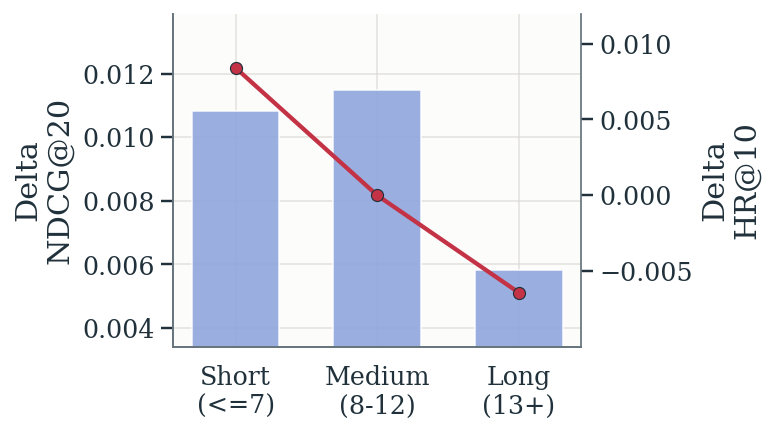

In [7]:
plot_bin_panel('KuaiRecLargeStrictPosV2_0.2', 'session', 'a04_special_bins_kuairec_session.pdf')

KuaiRec | target-frequency bins
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a04_special_bins_kuairec_freq.pdf


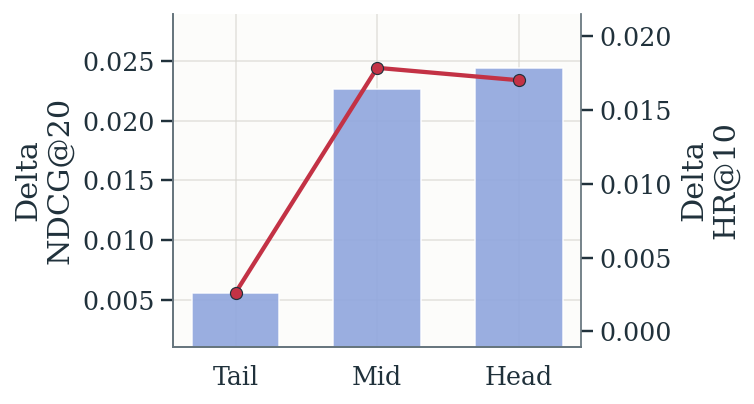

In [8]:
plot_bin_panel('KuaiRecLargeStrictPosV2_0.2', 'freq', 'a04_special_bins_kuairec_freq.pdf')

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a04_special_bins_metric_legend.pdf


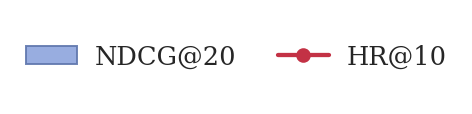

In [15]:
fig, ax = half_legend_strip_axes()
ax.legend(handles=metric_legend_handles(), loc='center', ncol=2, frameon=False, columnspacing=1.6, handletextpad=0.7)
fig.savefig(FIG_DIR / 'a04_special_bins_metric_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a04_special_bins_metric_legend.pdf')
plt.show()